In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [21]:
!pip install kaggle -q

In [16]:
# Import necessary libraries
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [24]:

path = kagglehub.dataset_download("uciml/indian-liver-patient-records")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 7.68k/7.68k [00:00<00:00, 504kB/s]

Extracting files...


Path to dataset files: C:\Users\CL-3\.cache\kagglehub\datasets\uciml\indian-liver-patient-records\versions\1


Epoch 1/10


C:\Users\CL-3\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


570/570 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7979 - loss: 0.4380 - val_accuracy: 0.8454 - val_loss: 0.3418
Epoch 2/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8372 - loss: 0.3576 - val_accuracy: 0.8465 - val_loss: 0.3284
Epoch 3/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8417 - loss: 0.3412 - val_accuracy: 0.8484 - val_loss: 0.3219
Epoch 4/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8454 - loss: 0.3327 - val_accuracy: 0.8508 - val_loss: 0.3204
Epoch 5/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8511 - loss: 0.3284 - val_accuracy: 0.8537 - val_loss: 0.3183
Epoch 6/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8506 - loss: 0.3248 - val_accuracy: 0.8555 - val_loss: 0.3175
Epoch 7/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8547 - loss: 0.3196 - val_accuracy: 0.8568 - val_loss: 0.3161
Epoch 8/10
570/570 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8520 - loss: 0.3197 - val_accuracy: 0.8561 - val_

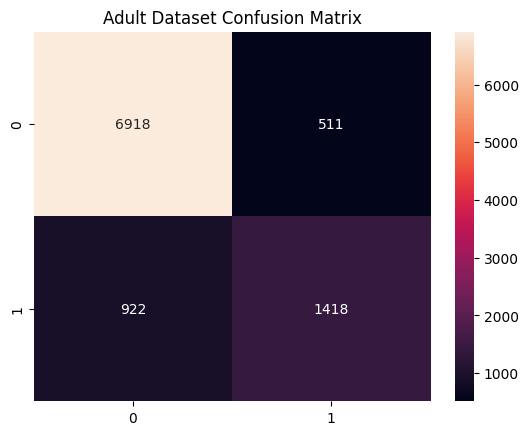

In [10]:
path = kagglehub.dataset_download("uciml/adult-census-income")
df = pd.read_csv(os.path.join(path, "adult.csv"))

# Preprocessing
df = df.replace(" ?", np.nan).dropna()

# ✅ Separate target first (BEST WAY)
y = df["income"].apply(lambda x: 1 if ">50K" in x else 0)
X = df.drop("income", axis=1)

# Encode features
X = pd.get_dummies(X)

# Scale
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model
model = build_model(X_train.shape[1])
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate
evaluate_model(model, X_test, y_test, "Adult Dataset")

Epoch 1/10


C:\Users\CL-3\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4568 - loss: 0.7421 - val_accuracy: 0.5926 - val_loss: 0.6553
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6358 - loss: 0.6469 - val_accuracy: 0.7778 - val_loss: 0.5951
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6975 - loss: 0.5918 - val_accuracy: 0.7778 - val_loss: 0.5682
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6852 - loss: 0.5929 - val_accuracy: 0.7778 - val_loss: 0.5505
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7407 - loss: 0.5669 - val_accuracy: 0.7778 - val_loss: 0.5385
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7099 - loss: 0.5687 - val_accuracy: 0.7778 - val_loss: 0.5244
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7438 - loss: 0.5664 - val_accuracy: 0.7778 - val_loss: 0.5134
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7253 - loss: 0.5427 - val_accuracy: 0.7778 - val_loss: 0.5132
Ep

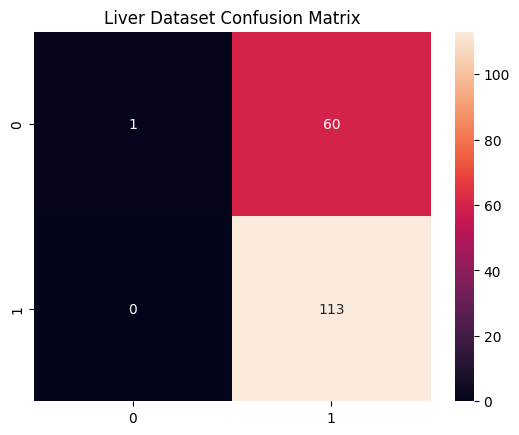

In [8]:
path = kagglehub.dataset_download("uciml/indian-liver-patient-records")
df = pd.read_csv(os.path.join(path, "indian_liver_patient.csv"))

# Preprocessing
df = df.dropna()

# Fix target (IMPORTANT)
df["Dataset"] = df["Dataset"].replace({2: 0})

# Encode Gender
df = pd.get_dummies(df, columns=["Gender"], drop_first=True)

X = df.drop("Dataset", axis=1)
y = df["Dataset"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = build_model(X_train.shape[1])
model.fit(X_train, y_train, epochs=10, batch_size=16, validation_split=0.2)

evaluate_model(model, X_test, y_test, "Liver Dataset")

Original Columns: Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')
Epoch 1/10


C:\Users\CL-3\AppData\Local\Temp\ipykernel_11032\3031365775.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
C:\Users\CL-3\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kw

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7295 - loss: 0.6100 - val_accuracy: 0.7554 - val_loss: 0.5798
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7350 - loss: 0.5770 - val_accuracy: 0.7554 - val_loss: 0.5391
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7391 - loss: 0.5509 - val_accuracy: 0.7554 - val_loss: 0.5135
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7541 - loss: 0.5271 - val_accuracy: 0.7554 - val_loss: 0.4948
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7432 - loss: 0.5269 - val_accuracy: 0.7772 - val_loss: 0.4832
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7541 - loss: 0.5038 - val_accuracy: 0.7935 - val_loss: 0.4745
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7568 - loss: 0.5156 - val_accuracy: 0.7935 - val_loss: 0.4716
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7486 - loss: 0.5082 - val_accuracy: 0.7989 - val_loss: 0.4681
Epo

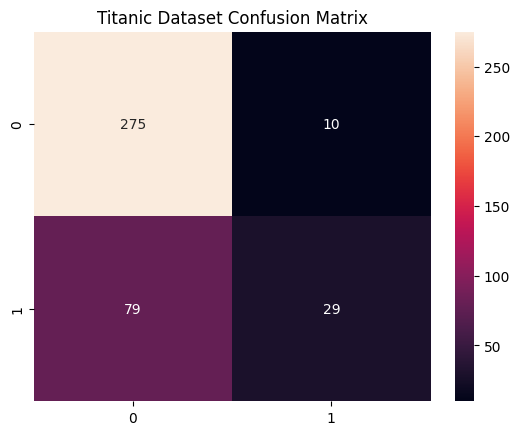

In [5]:
path = kagglehub.dataset_download("heptapod/titanic")
df = pd.read_csv(os.path.join(path, "train_and_test2.csv"))
print("Original Columns:", df.columns)
df.columns = df.columns.str.strip().str.lower()
df.rename(columns={
    "sibsp": "SibSp",
    "parch": "Parch",
    "pclass": "Pclass",
    "sex": "Sex",
    "age": "Age",
    "fare": "Fare",
    "embarked": "Embarked",
    "2urvived": "Survived"  
}, inplace=True)
df = df[["Pclass","Sex","Age","SibSp","Parch","Fare","Embarked","Survived"]]
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)
X = df.drop("Survived", axis=1)
y = df["Survived"]
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
model = build_model(X_train.shape[1])
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
evaluate_model(model, X_test, y_test, "Titanic Dataset")